## Image classification problem

1.0.1 Part 1: Preprocessing

1) Load the Mnist dataset using on train_X, train_y, test_X, and test_y datasets. Then,
print the type and the shape of each dataset.

In [1]:
import numpy as np
data = np.load('mnist.npz')
train_X = data['train_X']
train_y = data['train_y']
test_X = data['test_X']
test_y = data['test_y']
# Print type and shape
print("train_X:", type(train_X), train_X.shape)
print("train_y:", type(train_y), train_y.shape)
print("test_X:", type(test_X), test_X.shape)
print("test_y:", type(test_y), test_y.shape)

train_X: <class 'numpy.ndarray'> (10000, 28, 28)
train_y: <class 'numpy.ndarray'> (10000,)
test_X: <class 'numpy.ndarray'> (1000, 28, 28)
test_y: <class 'numpy.ndarray'> (1000,)


2) Visualize some images:

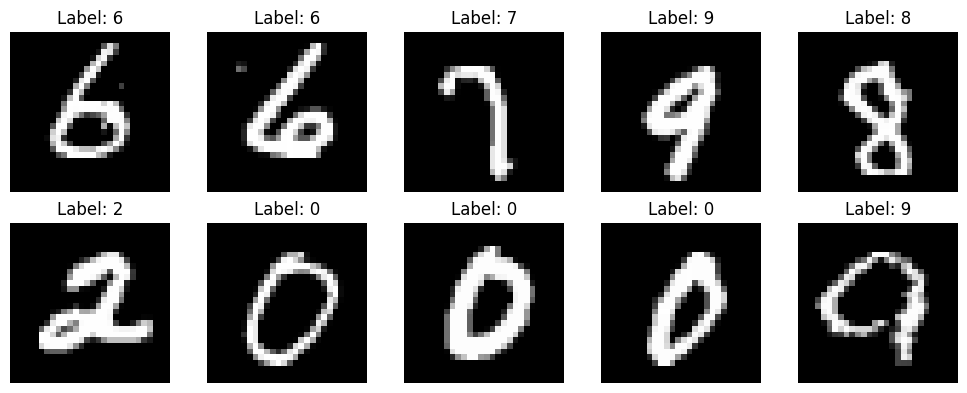

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(train_X[i], cmap='gray')
    ax.set_title(f"Label: {train_y[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

3) Normalize the data to scale them within the range [0, 1] by dividing each value by 255.
After normalization, vectorize the data into new variables named normv_train_X and
normv_test_X. What are the new shapes of these varia

In [3]:
# Normalize to [0, 1]
normv_train_X = train_X / 255.0
normv_test_X  = test_X  / 255.0

# Vectorize (flatten each image)
normv_train_X = normv_train_X.reshape(normv_train_X.shape[0], -1)
normv_test_X  = normv_test_X.reshape(normv_test_X.shape[0],  -1)

print("normv_train_X shape:", normv_train_X.shape)  
print("normv_test_X shape:",  normv_test_X.shape)

normv_train_X shape: (10000, 784)
normv_test_X shape: (1000, 784)


4) Transform the true labels into a binary matrix using the to_categorical function, where
each label is represented as a binary vector with a 1 at the index of the class value and 0 for
all other classes.

In [5]:
from tensorflow.keras.utils import to_categorical

train_y_cat = to_categorical(train_y)
test_y_cat  = to_categorical(test_y)

print("train_y_cat shape:", train_y_cat.shape)
print("test_y_cat shape:",  test_y_cat.shape)

I0000 00:00:1775210671.432190 1814734 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775210671.487276 1814734 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775210676.900958 1814734 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


train_y_cat shape: (10000, 10)
test_y_cat shape: (1000, 10)


1.0.2 Part 2: Build, train and evaluate a Deep Neural Network

5) Construct a Deep Neural Network with one hidden layer containing 128 units using the Leaky
ReLU activation function, and employ the sigmoid activation for the final layer.

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU

model_dnn = Sequential([
    Dense(128, input_shape=(normv_train_X.shape[1],)),
    LeakyReLU(),
    Dense(10, activation='sigmoid')  # 10 classes for MNIST
])

model_dnn.summary()

/home/darix/.local/share/uv/tools/jupyterlab/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1775210680.107632 1814734 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

6) Train the model for 20 epochs using the Adam optimizer with a learning rate equal to

In [7]:
from tensorflow.keras.optimizers import Adam

model_dnn.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_dnn = model_dnn.fit(
    normv_train_X, train_y_cat,
    epochs=20,
    batch_size=32,
    validation_data=(normv_test_X, test_y_cat)
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8254 - loss: 0.6543 - val_accuracy: 0.8800 - val_loss: 0.4191
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9109 - loss: 0.3156 - val_accuracy: 0.8970 - val_loss: 0.3493
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9277 - loss: 0.2608 - val_accuracy: 0.8990 - val_loss: 0.3182
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9344 - loss: 0.2304 - val_accuracy: 0.9100 - val_loss: 0.2963
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9438 - loss: 0.2041 - val_accuracy: 0.9160 - val_loss: 0.2825
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9475 - loss: 0.1850 - val_accuracy: 0.9090 - val_loss: 0.2813
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9534 - loss: 0.1656 - val_accuracy: 0.9160 - val_loss: 0.2788
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9572 - loss: 0.1524 - val_accuracy: 0.

7) Plot the accuracy and loss at each epoch for both training and test sets. Comment.

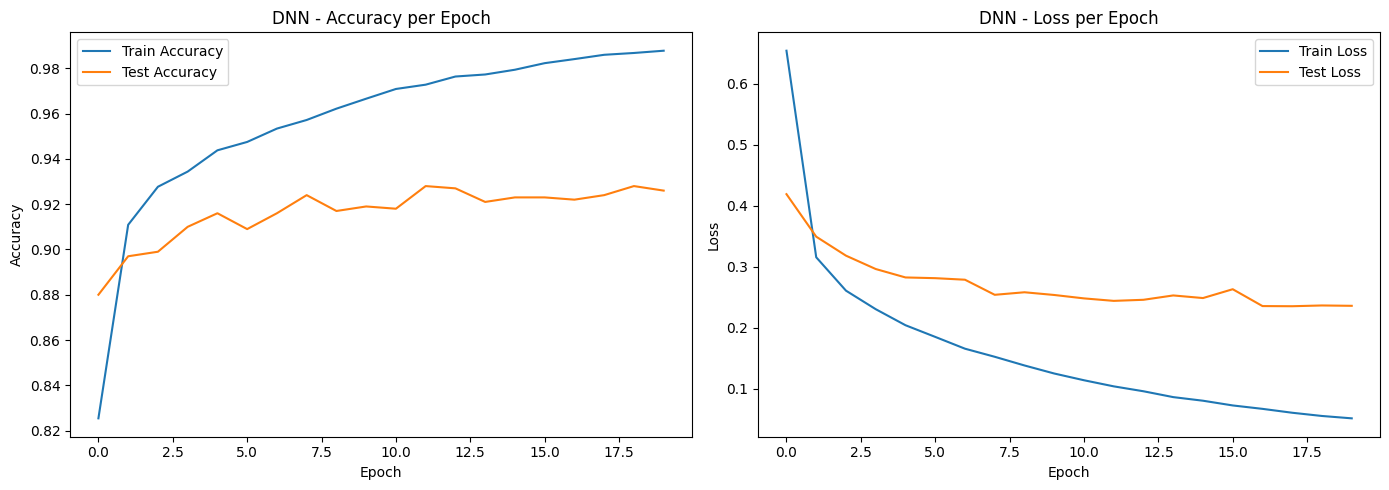

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history_dnn.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history_dnn.history['val_accuracy'], label='Test Accuracy')
axes[0].set_title('DNN - Accuracy per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history_dnn.history['loss'],     label='Train Loss')
axes[1].plot(history_dnn.history['val_loss'], label='Test Loss')
axes[1].set_title('DNN - Loss per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

# Comment:
since train accuracy >> val accuracy => overfitting


1.0.3 Part 3: Build, train and evaluate a Convolutional Neural Network

8) Reshape the train and test data by considering the number of channels.

In [9]:
# MNIST images: 28x28 -> 28x28x1 (grayscale = 1 channel)
train_X_cnn = (train_X / 255.0).reshape(-1, 28, 28, 1)
test_X_cnn  = (test_X  / 255.0).reshape(-1, 28, 28, 1)

print("train_X_cnn shape:", train_X_cnn.shape)  
print("test_X_cnn shape:",  test_X_cnn.shape)

train_X_cnn shape: (10000, 28, 28, 1)
test_X_cnn shape: (1000, 28, 28, 1)


9) Then build the CNN, shown in the figure bellow, (kernel_size =
(3,3), padding = “same” with sigmoid activation for the last layer)

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, LeakyReLU, BatchNormalization,
                                      Flatten, Dense)

def conv_block(filters, strides=1):
    return [
        Conv2D(filters, kernel_size=(3,3), strides=strides, padding='same'),
        LeakyReLU(),
        BatchNormalization()
    ]

model_cnn = Sequential([
    # Conv1 - s=1 -> 28x28x16
    *conv_block(16, strides=1),

    # Conv2 - s=1 -> 28x28x16
    *conv_block(16, strides=1),

    # Conv3 - s=2 -> 14x14x32
    *conv_block(32, strides=2),

    # Conv4 - s=2 -> 7x7x64
    *conv_block(64, strides=2),

    # Conv5 - s=2 -> 4x4x128
    *conv_block(128, strides=2),

    # Flatten -> 2048
    Flatten(),

    # FC6 -> 256
    Dense(256),
    LeakyReLU(),

    # FC7 / Output -> 10
    Dense(10, activation='sigmoid')
])

model_cnn.build(input_shape=(None, 28, 28, 1))
model_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 627,610 (2.39 MB)

 Trainable params: 627,098 (2.39 MB)

 Non-trainable params: 512 (2.00 KB)

10) Train the model for 20 epochs using the Adam optimizer with a learning rate equal to 0.001
and CategoricalCrossentropy loss. Evaluate the model using the accuracy metri

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.9036 - loss: 0.3450 - val_accuracy: 0.5770 - val_loss: 1.3661
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.9548 - loss: 0.1442 - val_accuracy: 0.9530 - val_loss: 0.1419
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.9664 - loss: 0.0995 - val_accuracy: 0.9390 - val_loss: 0.1013
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.9689 - loss: 0.0762 - val_accuracy: 0.9280 - val_loss: 0.1826
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.9631 - loss: 0.0839 - val_accuracy: 0.9120 - val_loss: 0.2647
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.9548 - loss: 0.0574 - val_accuracy: 0.9060 - val_loss: 0.1236
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.9490 - loss: 0.0592 - val_accuracy: 0.8930 - val_loss: 0.1531
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.9548 - loss: 0.0440 - 

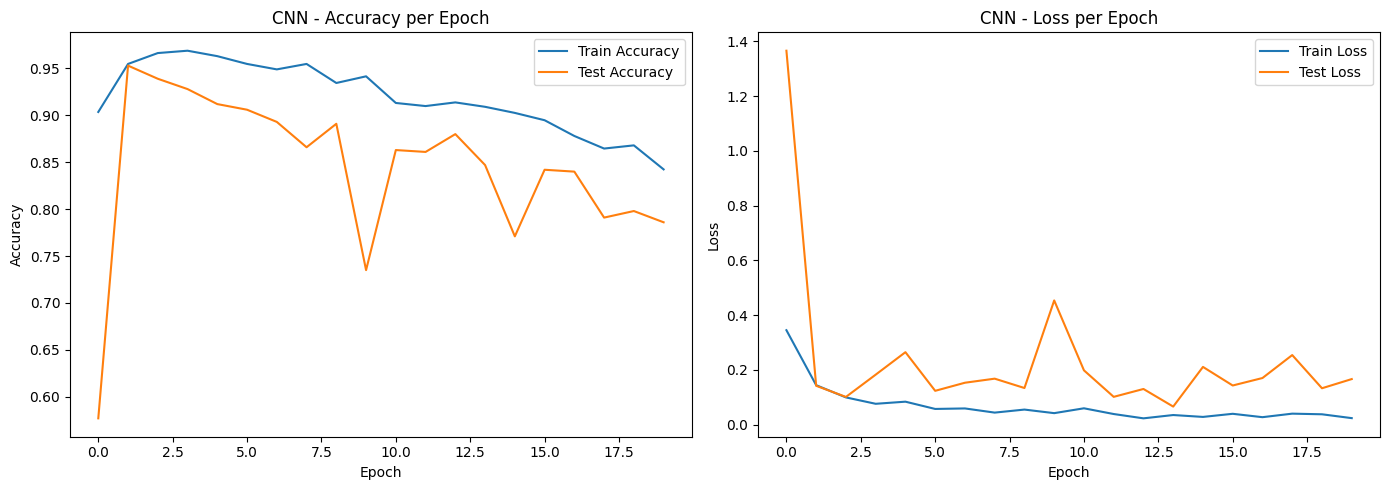

In [11]:
model_cnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn = model_cnn.fit(
    train_X_cnn, train_y_cat,
    epochs=20,
    batch_size=32,
    validation_data=(test_X_cnn, test_y_cat)
)

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_cnn.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history_cnn.history['val_accuracy'], label='Test Accuracy')
axes[0].set_title('CNN - Accuracy per Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_cnn.history['loss'],     label='Train Loss')
axes[1].plot(history_cnn.history['val_loss'], label='Test Loss')
axes[1].set_title('CNN - Loss per Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

# Comment:

since both train and test converge the actual model have good generalisation

1.0.4 BONUS: Save and load models

11) Save the trained CNN in a directory and load it.

In [13]:
import os


save_dir = './saved_models'
os.makedirs(save_dir, exist_ok=True)
model_cnn.save(os.path.join(save_dir, 'cnn_mnist.keras'))
print("Model saved!")


from tensorflow.keras.models import load_model
loaded_model = load_model(os.path.join(save_dir, 'cnn_mnist.keras'))
print("Model loaded!")


loss, acc = loaded_model.evaluate(test_X_cnn, test_y_cat)
print(f"Loaded model - Test Accuracy: {acc:.4f}")

Model saved!
Model loaded!
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7860 - loss: 0.1665
Loaded model - Test Accuracy: 0.7860
